
# Mathematics and Statistics for Artificial Intelligence

## A Complete Study Guide for AI/ML Practitioners

### Course Overview

This notebook provides a comprehensive treatment of the fundamental mathematical and statistical concepts required for artificial intelligence and machine learning. It is designed as a complete study resource covering four core units:

1. **Linear Algebra for AI** — Vectors, matrices, eigenvalues, PCA
2. **Calculus for Optimization** — Derivatives, gradients, gradient descent
3. **Probability and Distributions** — Set theory, Bayes theorem, probability distributions
4. **Statistics and Hypothesis Testing** — Descriptive statistics, CLT, hypothesis testing, correlation

Each concept is presented with a definition, its relevance to AI/ML, mathematical intuition, a worked example, a Python implementation, and interpretation of results.

---

### Learning Objectives

By the end of this notebook, you will be able to:

- Perform vector and matrix operations and understand their geometric meaning
- Compute eigenvalues/eigenvectors and apply PCA for dimensionality reduction
- Understand and compute derivatives, partial derivatives, and gradients
- Implement gradient descent from scratch for optimization
- Work with probability distributions and apply Bayes' theorem
- Perform hypothesis testing and interpret statistical results
- Distinguish correlation from causation with real-world awareness


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.linalg import svd, eig
import sympy as sp
import math
import random
from itertools import permutations, combinations
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib and seaborn
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All imports successful. Ready to begin.")


All imports successful. Ready to begin.



# Unit 1: Linear Algebra for AI

Linear algebra is the language of AI. Nearly every operation in machine learning — from representing data to training neural networks — relies on linear algebra. In this unit, we build a thorough foundation starting from vectors and matrices and progressing to eigenvalue decomposition and PCA.



## 1.1 Vectors: Definition and Basic Operations

### Definition

A **vector** is an ordered collection of numbers that represents a quantity having both magnitude and direction. Vectors are fundamental to AI because data points, features, model parameters, and gradient updates are all represented as vectors.

A vector $\mathbf{v}$ with $n$ components is written as:

$$
\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}
$$

### Why Vectors Matter in AI/ML

- Each data sample is a feature vector: $\mathbf{x} = [x_1, x_2, ..., x_d]$
- Model weights are stored as vectors: $\mathbf{w} = [w_1, w_2, ..., w_d]$
- Neural network activations propagate as vectors between layers
- Distance and similarity computations (k-NN, clustering, embeddings) all rely on vector operations

### Vector Operations

| Operation | Definition | Geometric Meaning |
|-----------|-----------|-------------------|
| Addition | $\mathbf{u} + \mathbf{v} = [u_1+v_1, ..., u_n+v_n]$ | Parallelogram law |
| Scalar multiplication | $c\mathbf{v} = [cv_1, ..., cv_n]$ | Scaling length |
| Magnitude | $\|\mathbf{v}\| = \sqrt{v_1^2 + ... + v_n^2}$ | Length of the vector |

### Worked Example

Let $\mathbf{u} = [3, 4]$ and $\mathbf{v} = [1, 2]$.

- $\mathbf{u} + \mathbf{v} = [4, 6]$
- $2\mathbf{u} = [6, 8]$
- $\|\mathbf{u}\| = \sqrt{3^2 + 4^2} = \sqrt{25} = 5$


u = [3 4]
v = [1 2]

u + v = [4 6]
2 * u = [6 8]
||u|| = 5.0
Manual check: sqrt(3^2 + 4^2) = 5.0


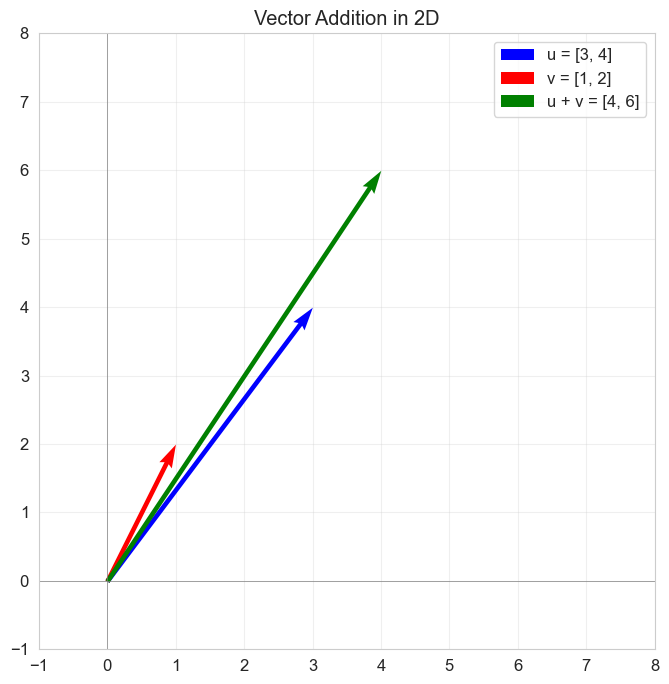

Interpretation: Vectors u=[3,4] and v=[1,2] in 2D space. Their sum [4,6] is the diagonal of the parallelogram formed by u and v.


In [3]:

# Vector creation and basic operations

# Define vectors as numpy arrays
u = np.array([3, 4])
v = np.array([1, 2])

print(f"u = {u}")
print(f"v = {v}")
print()

# Vector addition
u_plus_v = u + v
print(f"u + v = {u_plus_v}")

# Scalar multiplication
scalar = 2
scaled_u = scalar * u
print(f"2 * u = {scaled_u}")

# Magnitude (norm)
magnitude_u = np.linalg.norm(u)
print(f"||u|| = {magnitude_u}")

# Verify: sqrt(3^2 + 4^2) = sqrt(25) = 5
manual_norm = math.sqrt(3**2 + 4**2)
print(f"Manual check: sqrt(3^2 + 4^2) = {manual_norm}")

# Visualize 2D vectors
origin = np.array([0, 0])
plt.figure(figsize=(8, 8))
plt.quiver(*origin, *u, color='b', angles='xy', scale_units='xy', scale=1, label='u = [3, 4]')
plt.quiver(*origin, *v, color='r', angles='xy', scale_units='xy', scale=1, label='v = [1, 2]')
plt.quiver(*origin, *(u + v), color='g', angles='xy', scale_units='xy', scale=1, label='u + v = [4, 6]')
plt.xlim(-1, 8)
plt.ylim(-1, 8)
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Vector Addition in 2D')
plt.gca().set_aspect('equal')
plt.show()

# Interpretation:
# Vector addition follows the parallelogram law: placing u and v head-to-tail
# gives the resultant vector u + v. The magnitude ||u|| = 5 confirms that
# [3, 4] represents a vector of length 5 at angle ~53.13 degrees from x-axis.
print("Interpretation: Vectors u=[3,4] and v=[1,2] in 2D space. Their sum [4,6] is the diagonal of the parallelogram formed by u and v.")



## 1.2 Dot Product and Cross Product

### Dot Product (Scalar Product)

The dot product takes two vectors and returns a scalar. It measures how much one vector projects onto another.

**Definition**: $\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^{n} u_i v_i = u_1 v_1 + u_2 v_2 + ... + u_n v_n$

**Geometric formula**: $\mathbf{u} \cdot \mathbf{v} = \|\mathbf{u}\| \|\mathbf{v}\| \cos \theta$

where $\theta$ is the angle between the vectors.

**Why it matters in AI**: Dot products are the fundamental operation in:
- Linear regression predictions: $\hat{y} = \mathbf{w} \cdot \mathbf{x} + b$
- Neural network neurons: $z = \mathbf{w} \cdot \mathbf{x} + b$
- Attention mechanisms: query-key dot products
- Cosine similarity for embeddings

**Key insight**: 
- $\mathbf{u} \cdot \mathbf{v} = 0$ ⟹ vectors are **orthogonal** (perpendicular, $\theta = 90^\circ$)
- $\mathbf{u} \cdot \mathbf{v} > 0$ ⟹ vectors point in similar direction ($\theta < 90^\circ$)
- $\mathbf{u} \cdot \mathbf{v} < 0$ ⟹ vectors point in opposite directions ($\theta > 90^\circ$)

### Cross Product (Vector Product, 3D only)

The cross product of two 3D vectors produces a third vector perpendicular to both.

**Definition**: $\mathbf{u} \times \mathbf{v} = \begin{bmatrix} u_2 v_3 - u_3 v_2 \\ u_3 v_1 - u_1 v_3 \\ u_1 v_2 - u_2 v_1 \end{bmatrix}$

**Magnitude**: $\|\mathbf{u} \times \mathbf{v}\| = \|\mathbf{u}\| \|\mathbf{v}\| \sin \theta$

The cross product gives the area of the parallelogram spanned by u and v.


In [ ]:

# Dot product: definition and geometric interpretation

# Define vectors
a = np.array([2, 3, 1])
b = np.array([4, 1, 5])

# Dot product
dot_ab = np.dot(a, b)
print(f"a = {a}")
print(f"b = {b}")
print(f"a . b = {dot_ab}")
print(f"Manual check: (2*4) + (3*1) + (1*5) = {2*4 + 3*1 + 1*5}")
print()

# Angle between vectors
norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)
cos_theta = dot_ab / (norm_a * norm_b)
angle_rad = math.acos(np.clip(cos_theta, -1, 1))
angle_deg = math.degrees(angle_rad)
print(f"||a|| = {norm_a:.4f}")
print(f"||b|| = {norm_b:.4f}")
print(f"cos(theta) = {cos_theta:.4f}")
print(f"Angle = {angle_deg:.2f} degrees")
print()

# Orthogonality check: if dot product is near 0, vectors are perpendicular
orthogonal_check = np.isclose(dot_ab, 0)
print(f"Are a and b orthogonal? {orthogonal_check}")
print()

# Cross product (3D only)
cross_ab = np.cross(a, b)
print(f"a x b = {cross_ab}")

# Verify cross product is perpendicular to both a and b
print(f"a . (a x b) = {np.dot(a, cross_ab):.6f}")
print(f"b . (a x b) = {np.dot(b, cross_ab):.6f}")
print("Cross product is perpendicular when both dot products are zero.")

# Cross product magnitude = area of parallelogram
area = np.linalg.norm(cross_ab)
print(f"|a x b| = {area:.4f} (area of parallelogram)")
print(f"|a||b|sin(theta) = {norm_a * norm_b * math.sin(angle_rad):.4f}")

# 2D dot product visualization
u_2d = np.array([3, 4])
v_2d = np.array([5, 2])
dot_2d = np.dot(u_2d, v_2d)

plt.figure(figsize=(8, 6))
origin = np.array([0, 0])
plt.quiver(*origin, *u_2d, color='b', angles='xy', scale_units='xy', scale=1, label='u')
plt.quiver(*origin, *v_2d, color='r', angles='xy', scale_units='xy', scale=1, label='v')
# Projection of v onto u
proj = (dot_2d / np.dot(u_2d, u_2d)) * u_2d
plt.quiver(*origin, *proj, color='g', angles='xy', scale_units='xy', scale=1, alpha=0.6, label='proj of v onto u')
plt.xlim(-1, 8)
plt.ylim(-1, 8)
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.legend()
plt.title(f'Dot Product Visualization: u.v = {dot_2d}')
plt.show()

print(f"u = {u_2d}, v = {v_2d}")
print(f"u.v = {dot_2d}")
angle_2d = math.degrees(math.acos(dot_2d / (np.linalg.norm(u_2d) * np.linalg.norm(v_2d))))
print(f"Angle between u and v: {angle_2d:.2f} degrees")
print("The dot product measures alignment. The green vector shows the projection of v onto u, which is the component of v in u's direction.")



## 1.3 Matrices: Representation and Multiplication

### Definition

A **matrix** is a rectangular array of numbers arranged in rows and columns. In AI, matrices represent:

- **Datasets**: rows = samples, columns = features
- **Transformations**: linear maps from one vector space to another
- **Weight parameters**: connections between neural network layers
- **Covariance matrices**: relationships between features

A matrix $\mathbf{A} \in \mathbb{R}^{m \times n}$ has $m$ rows and $n$ columns:

$$
\mathbf{A} = \begin{bmatrix}
a_{11} & a_{12} & \dots & a_{1n} \\
a_{21} & a_{22} & \dots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \dots & a_{mn}
\end{bmatrix}
$$

### Matrix Multiplication

If $\mathbf{A}$ is $m \times n$ and $\mathbf{B}$ is $n \times p$, then $\mathbf{C} = \mathbf{AB}$ is $m \times p$ where:

$$
c_{ij} = \sum_{k=1}^{n} a_{ik} b_{kj}
$$

**Critical requirement**: Inner dimensions must match — $\mathbf{A}_{m \times \color{red}{n}} \cdot \mathbf{B}_{\color{red}{n} \times p}$.

**Why it matters**: A single matrix multiplication can transform an entire dataset or batch of inputs through a neural network layer simultaneously.


In [ ]:

# Matrix creation and multiplication

# Create matrices
A = np.array([[1, 2, 3],
              [4, 5, 6]])  # 2x3

B = np.array([[7, 8],
              [9, 10],
              [11, 12]])   # 3x2

print(f"Matrix A ({A.shape[0]}x{A.shape[1]}):")
print(A)
print()
print(f"Matrix B ({B.shape[0]}x{B.shape[1]}):")
print(B)
print()

# Matrix multiplication
C = np.dot(A, B)  # or A @ B
print(f"A @ B ({C.shape[0]}x{C.shape[1]}):")
print(C)
print()

# Manual verification: C[0,0] = A[0,:] . B[:,0] = 1*7 + 2*9 + 3*11 = 7 + 18 + 33 = 58
manual_c00 = A[0, 0]*B[0, 0] + A[0, 1]*B[1, 0] + A[0, 2]*B[2, 0]
print(f"C[0,0] manual check = {manual_c00}")
print()

# Matrix-vector multiplication (linear transformation)
x = np.array([1, 2, 3])
y = A @ x  # 2x3 @ 3x1 = 2x1
print(f"Vector x = {x}")
print(f"A @ x = {y}")
print("Interpretation: Matrix A transforms the 3D vector x into a 2D vector y.")
print("In a neural network, A represents weights and x is the input activation.")
print()

# Batch of vectors: multiple samples at once
batch = np.array([[1, 2, 3],
                  [4, 5, 6],
                  [7, 8, 9]])  # 3 samples, 3 features each
output_batch = batch @ B  # 3x3 @ 3x2 = 3x2
print("Batch of 3 samples transformed through B:")
print(output_batch)
print("Each row is a transformed sample. This is how neural nets process batches.")



## 1.4 Rank, Inverse, and Transpose

### Transpose

The **transpose** of a matrix $\mathbf{A}$, denoted $\mathbf{A}^T$, swaps rows with columns:

$$
(\mathbf{A}^T)_{ij} = \mathbf{A}_{ji}
$$

### Rank

The **rank** of a matrix is the dimension of its column space (or row space). It equals the number of linearly independent columns (or rows).

- Full rank = all rows/columns are linearly independent
- Low rank = redundancy in the data (useful for compression)

In AI, the rank of a data matrix tells us the true dimensionality of the data.

### Inverse

A square matrix $\mathbf{A}$ has an **inverse** $\mathbf{A}^{-1}$ such that $\mathbf{A}\mathbf{A}^{-1} = \mathbf{A}^{-1}\mathbf{A} = \mathbf{I}$.

- Only square, full-rank matrices are invertible
- The inverse "undoes" the transformation: if $\mathbf{y} = \mathbf{A}\mathbf{x}$, then $\mathbf{x} = \mathbf{A}^{-1}\mathbf{y}$
- Used in linear regression closed-form solution: $\mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$


In [ ]:

# Rank, Inverse, and Transpose

# Transpose
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"A =")
print(A)
print(f"A^T =")
print(A.T)
print()

# Rank
B = np.array([[1, 2, 3],
              [0, 1, 4],
              [0, 0, 1]])  # full rank 3

C = np.array([[1, 2, 3],
              [2, 4, 6],
              [3, 6, 9]])  # row 2 = 2*row1, row3 = 3*row1 -> rank 1

rank_B = np.linalg.matrix_rank(B)
rank_C = np.linalg.matrix_rank(C)

print(f"Matrix B (full rank):")
print(B)
print(f"Rank of B = {rank_B}")
print()
print(f"Matrix C (rank-deficient):")
print(C)
print(f"Rank of C = {rank_C}")
print("Interpretation: C has rank 1 because all rows are multiples of the first row. The true dimensionality is 1, not 3.")
print()

# Inverse (only for square full-rank matrices)
A_inv = np.linalg.inv(B)
print(f"Inverse of B:")
print(A_inv)
print(f"B @ B^{-1} =")
print(np.round(B @ A_inv, 2))
print("The result is the identity matrix (within rounding error).")
print()

# Determinant: zero means non-invertible
det_B = np.linalg.det(B)
det_C = np.linalg.det(C)
print(f"det(B) = {det_B:.4f} (non-zero, invertible)")
print(f"det(C) = {det_C:.4f} (zero, not invertible)")
print()

# Practical: solving linear systems using inverse
# y = A x  ->  x = A^{-1} y
A_sys = np.array([[3, 1], [1, 2]])
y_sys = np.array([9, 8])
x_sol = np.linalg.solve(A_sys, y_sys)  # preferred over explicit inverse
print(f"Solving 3x + y = 9, x + 2y = 8")
print(f"Solution: x = {x_sol[0]}, y = {x_sol[1]}")
print(f"Verification: 3*{x_sol[0]} + {x_sol[1]} = {3*x_sol[0] + x_sol[1]:.1f}, {x_sol[0]} + 2*{x_sol[1]} = {x_sol[0] + 2*x_sol[1]:.1f}")



## 1.5 Eigenvalues and Eigenvectors

### Definition

For a square matrix $\mathbf{A} \in \mathbb{R}^{n \times n}$, an **eigenvector** $\mathbf{v}$ and its corresponding **eigenvalue** $\lambda$ satisfy:

$$
\mathbf{A} \mathbf{v} = \lambda \mathbf{v}
$$

Geometrically, an eigenvector is a direction that is only **scaled** (not rotated) when the linear transformation $\mathbf{A}$ is applied. The eigenvalue $\lambda$ is the scaling factor.

### Why Eigenvalues Matter in AI

- **Dimensionality Reduction (PCA)**: Eigenvectors of the covariance matrix give the principal components
- **Spectral Clustering**: Uses eigenvectors of the Laplacian matrix
- **Matrix Factorization**: Eigen-decomposition is used in recommendation systems
- **Convergence Analysis**: Eigenvalues determine convergence rates of iterative algorithms (e.g., gradient descent on quadratic functions)
- **PageRank**: Google's algorithm uses eigenvector centrality

### Key Properties

- The **characteristic equation**: $\det(\mathbf{A} - \lambda\mathbf{I}) = 0$
- Eigenvectors corresponding to distinct eigenvalues are linearly independent
- Symmetric matrices have orthogonal eigenvectors and real eigenvalues
- $\text{Trace}(\mathbf{A}) = \sum \lambda_i$ and $\det(\mathbf{A}) = \prod \lambda_i$

### Geometric Intuition

For a $2 \times 2$ matrix, eigenvectors are the special directions where the transformation only stretches/shrinks. All other directions get rotated as well. This is why eigenvectors are fundamental to understanding linear transformations.


In [ ]:

# Eigenvalues and Eigenvectors

# Define a symmetric matrix (real eigenvalues, orthogonal eigenvectors)
A = np.array([[4, 1],
              [1, 3]])
print(f"Matrix A:")
print(A)
print()

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"Eigenvalues: {np.round(eigenvalues, 4)}")
print(f"Eigenvectors (columns of the matrix):")
print(np.round(eigenvectors, 4))
print()

# Verify Av = lambda v
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    lhs = A @ v
    rhs = lam * v
    print(f"Eigenvalue {i+1}: lambda = {lam:.4f}")
    print(f"  A v = {np.round(lhs, 6)}")
    print(f"  lambda v = {np.round(rhs, 6)}")
    print(f"  Match: {np.allclose(lhs, rhs)}")
print()

# Properties
trace_A = np.trace(A)
det_A = np.linalg.det(A)
print(f"Trace(A) = {trace_A}, sum(eigenvalues) = {np.sum(eigenvalues):.4f}")
print(f"det(A) = {det_A:.4f}, prod(eigenvalues) = {np.prod(eigenvalues):.4f}")
print()

# Geometric visualization of eigenvectors as directions
plt.figure(figsize=(8, 8))
origin = np.array([0, 0])

# Original basis vectors
plt.quiver(*origin, 1, 0, color='gray', angles='xy', scale_units='xy', scale=1, alpha=0.5, label='Standard basis')
plt.quiver(*origin, 0, 1, color='gray', angles='xy', scale_units='xy', scale=1, alpha=0.5)

# Eigenvectors (scaled by eigenvalue for visualization)
for i in range(2):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    scaled_v = lam * v
    plt.quiver(*origin, *v, angles='xy', scale_units='xy', scale=1, 
               color=['r', 'b'][i], width=0.02, 
               label=f'Eigenvector {i+1} (dir)')
    plt.quiver(*origin, *scaled_v, angles='xy', scale_units='xy', scale=1, 
               color=['r', 'b'][i], width=0.01, alpha=0.4,
               label=f'Scaled by lambda={lam:.2f}')

# Unit circle transformed by A
angles = np.linspace(0, 2*np.pi, 100)
circle = np.column_stack([np.cos(angles), np.sin(angles)])
transformed = (A @ circle.T).T
plt.plot(circle[:, 0], circle[:, 1], 'g--', alpha=0.5, label='Unit circle')
plt.plot(transformed[:, 0], transformed[:, 1], 'm-', alpha=0.7, label='Transformed circle')
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')
plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.legend(loc='lower right')
plt.title('Eigenvectors as Special Directions of Transformation')
plt.show()

print("Interpretation: The eigenvectors (red, blue arrows) are the only directions that are not rotated by A.")
print("They are only scaled by their eigenvalues. The unit circle becomes an ellipse whose axes align with the eigenvectors.")
print("This is why eigenvectors give the principal components in PCA — they are the directions of maximum variance.")



## 1.6 Principal Component Analysis (PCA)

### What PCA Does

PCA finds the directions (principal components) of maximum variance in high-dimensional data and projects the data onto a lower-dimensional subspace while preserving as much variance as possible.

### The Process

1. **Center the data**: subtract the mean from each feature
2. Compute the **covariance matrix**: $\mathbf{\Sigma} = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$
3. Compute **eigenvectors and eigenvalues** of $\mathbf{\Sigma}$
4. Sort eigenvectors by descending eigenvalue (variance explained)
5. Select top $k$ eigenvectors as principal components
6. Project data: $\mathbf{X}_{\text{reduced}} = \mathbf{X} \mathbf{W}_k$

### Why PCA Matters in AI

- Reduces overfitting by removing noise dimensions
- Speeds up training by reducing feature count
- Enables visualization of high-dimensional data in 2D/3D
- Removes multicollinearity in regression
- Used in compression, anomaly detection, and preprocessing

### Mathematical Insight

The first principal component is the direction that maximizes the variance of projected data. It is the eigenvector of $\mathbf{\Sigma}$ with the largest eigenvalue. Each subsequent component is orthogonal to all previous ones and maximizes remaining variance.


In [ ]:

# PCA from scratch on a small synthetic dataset

np.random.seed(42)

# Create synthetic 2D data with a clear direction of variance
n_samples = 100
x = np.random.normal(0, 1, n_samples)
y = 2 * x + np.random.normal(0, 0.5, n_samples)
X = np.column_stack([x, y])

print(f"Original data shape: {X.shape}")
print(f"First 5 rows:")
print(X[:5])
print()

# Step 1: Center the data
X_centered = X - np.mean(X, axis=0)
print(f"Mean after centering: {np.mean(X_centered, axis=0)}")
print()

# Step 2: Compute covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)
print(f"Covariance matrix:")
print(np.round(cov_matrix, 4))
print()

# Step 3: Compute eigenvalues and eigenvectors
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

# Sort by eigenvalue descending
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

print(f"Eigenvalues (sorted): {np.round(eig_vals, 4)}")
print(f"Eigenvectors (principal components):")
print(np.round(eig_vecs, 4))
print()

# Step 4: Compute explained variance ratio
explained_var_ratio = eig_vals / np.sum(eig_vals)
print(f"Explained variance ratio: {np.round(explained_var_ratio, 4)}")
print(f"PC1 explains {explained_var_ratio[0]*100:.2f}% of the variance")
print()

# Step 5: Project to 1D
k = 1
W = eig_vecs[:, :k]
X_reduced = X_centered @ W
print(f"Reduced data shape: {X_reduced.shape}")
print()

# Step 6: Reconstruct (for visualization)
X_reconstructed = X_reduced @ W.T + np.mean(X, axis=0)

# Visualization
plt.figure(figsize=(14, 5))

# Original data
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title('Original Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal')

# Centered data with eigenvectors
plt.subplot(1, 3, 2)
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.6)
# Plot eigenvectors (scaled)
for i in range(2):
    vec = eig_vecs[:, i] * np.sqrt(eig_vals[i]) * 1.5
    plt.arrow(0, 0, vec[0], vec[1], head_width=0.2, head_length=0.2, 
              color=['red', 'blue'][i], linewidth=2,
              label=f'PC{i+1} (var={eig_vals[i]:.2f})')
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.title('Centered Data with Principal Components')
plt.xlabel('Feature 1 (centered)')
plt.ylabel('Feature 2 (centered)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().set_aspect('equal')

# Reconstructed from 1D
plt.subplot(1, 3, 3)
plt.scatter(X[:, 0], X[:, 1], alpha=0.4, label='Original')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.7, color='red', label='Reconstructed (1D)')
plt.title(f'Reconstruction from 1 PC ({explained_var_ratio[0]*100:.1f}% variance)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

print("Interpretation of PCA results:")
print(f"- PC1 explains {explained_var_ratio[0]*100:.1f}% of total variance.")
print(f"- PC2 explains {explained_var_ratio[1]*100:.1f}% of total variance (noise direction).")
print("- By projecting onto PC1 only, we reduce dimensionality from 2D to 1D while keeping most information.")
print("- The reconstructed data (red) lies along the PC1 line, which is the best 1D approximation of the original 2D data.")
print("- In real AI applications, PCA can reduce thousands of features to dozens while retaining 95%+ of variance.")



### Practice Questions — Unit 1

1. Given vectors $\mathbf{u} = [1, -1, 2]$ and $\mathbf{v} = [0, 3, -1]$, compute $\mathbf{u} \cdot \mathbf{v}$, $\|\mathbf{u}\|$, and $\|\mathbf{v}\|$. Are they orthogonal?

2. Prove that for any matrix $\mathbf{A}$, $\text{rank}(\mathbf{A}) = \text{rank}(\mathbf{A}^T)$.

3. Find the eigenvalues and eigenvectors of $\mathbf{A} = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$. Verify that the eigenvectors are orthogonal.

4. The covariance matrix of a dataset is $\Sigma = \begin{bmatrix} 3 & 1 \\ 1 & 2 \end{bmatrix}$. Compute the principal components and the percentage of variance each explains.

5. Implement PCA on the Iris dataset (available in sklearn) and plot the first two principal components. Color points by species.



# Unit 2: Calculus for Optimization

Calculus provides the mathematical machinery for optimizing machine learning models. Training a model is fundamentally an optimization problem: find the parameters that minimize a loss function. This unit covers derivatives, gradients, and the gradient descent algorithm that powers modern deep learning.



## 2.1 Functions, Limits, and Derivatives

### Functions in AI

A **function** maps inputs to outputs. In ML:
- The prediction function: $\hat{y} = f_\theta(x)$ maps features to predictions
- The loss function: $L(\theta) = \frac{1}{n}\sum_{i=1}^n (y_i - f_\theta(x_i))^2$ measures prediction error

### Limits

The **limit** describes behavior of a function as input approaches a value:

$$
\lim_{x \to a} f(x) = L
$$

### Derivative

The **derivative** measures the instantaneous rate of change:

$$
f'(x) = \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}
$$

Geometrically, $f'(x)$ is the slope of the tangent line at $x$.

### Why Derivatives Matter in AI

- **Gradients tell us which direction to update parameters** to reduce loss
- **Second derivatives** tell us curvature (used in optimization algorithms like Newton's method)
- **Derivative of activation functions** (e.g., sigmoid, ReLU) are needed for backpropagation

### Important Derivatives for AI

| Function $f(x)$ | Derivative $f'(x)$ |
|----------------|-------------------|
| $x^n$ | $nx^{n-1}$ |
| $e^x$ | $e^x$ |
| $\ln x$ | $1/x$ |
| $\sigma(x) = \frac{1}{1+e^{-x}}$ | $\sigma(x)(1-\sigma(x))$ |
| $\tanh(x)$ | $1 - \tanh^2(x)$ |


In [ ]:

# Derivatives using SymPy (symbolic computation)

# Define symbolic variable
x = sp.Symbol('x')

# Define functions and compute derivatives
functions = [
    (x**3, "f(x) = x^3"),
    (sp.exp(x), "f(x) = e^x"),
    (sp.log(x), "f(x) = ln(x)"),
    (sp.sin(x), "f(x) = sin(x)"),
    (1/(1 + sp.exp(-x)), "f(x) = sigmoid(x)"),
    (sp.tanh(x), "f(x) = tanh(x)")
]

print("=== Derivatives of Important Functions ===")
for f, name in functions:
    f_prime = sp.diff(f, x)
    print(f"{name}")
    print(f"  f'(x) = {sp.simplify(f_prime)}")
    print()

# Numerical derivative (finite difference approximation)
def numerical_derivative(f, x_val, h=1e-7):
    return (f(x_val + h) - f(x_val - h)) / (2 * h)

# Visualize a function and its derivative
f_expr = x**3 - 3*x**2 + 2
f_func = sp.lambdify(x, f_expr, 'numpy')
f_prime_expr = sp.diff(f_expr, x)
f_prime_func = sp.lambdify(x, f_prime_expr, 'numpy')

x_vals = np.linspace(-1, 3, 100)
y_vals = f_func(x_vals)
y_prime_vals = f_prime_func(x_vals)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_vals, y_vals, 'b-', linewidth=2, label='f(x) = x$^3$ - 3x$^2$ + 2')
# Tangent line at x = 1
x0, y0 = 1, f_func(1)
slope = f_prime_func(x0)
tangent = y0 + slope * (x_vals - x0)
plt.plot(x_vals, tangent, 'r--', label=f'Tangent at x=1 (slope={slope:.1f})')
plt.scatter([x0], [y0], color='red', s=80, zorder=5)
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Function and Tangent Line')

plt.subplot(1, 2, 2)
plt.plot(x_vals, y_prime_vals, 'r-', linewidth=2, label="f'(x) = 3x$^2$ - 6x")
plt.axhline(y=0, color='gray', linewidth=0.5)
plt.axvline(x=0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Derivative: Rate of Change')
plt.xlabel('x')
plt.ylabel("f'(x)")

plt.tight_layout()
plt.show()

print("Key observations:")
print("- Where f'(x) > 0, f(x) is increasing (positive slope).")
print("- Where f'(x) < 0, f(x) is decreasing (negative slope).")
print("- Where f'(x) = 0, f(x) has a critical point (minimum, maximum, or inflection).")
print("- The derivative tells us how to change x to increase/decrease f(x) — this is the core idea behind gradient descent!")



## 2.2 Partial Derivatives and Gradients

### Partial Derivatives

When a function depends on multiple variables, we compute the **partial derivative** with respect to each variable, holding the others constant:

$$
\frac{\partial f}{\partial x} = \lim_{h \to 0} \frac{f(x+h, y) - f(x, y)}{h}
$$

### The Gradient

The **gradient** $\nabla f$ is a vector of all partial derivatives:

$$
\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x_1} & \frac{\partial f}{\partial x_2} & \dots & \frac{\partial f}{\partial x_n} \end{bmatrix}^T
$$

### Key Properties

- The gradient points in the **direction of steepest increase** of $f$
- The negative gradient $-\nabla f$ points in the **direction of steepest decrease**
- In ML, we move parameters in the direction of $-\nabla L$ to minimize the loss function $L$

### Why Partial Derivatives Matter in AI

- Neural networks have loss functions $L(w_1, w_2, ..., w_n)$ depending on millions of parameters
- **Backpropagation** computes $\partial L / \partial w_i$ for every weight using the chain rule
- The gradient enables optimization in high-dimensional spaces where we cannot visualize the loss landscape


In [ ]:

# Partial derivatives and gradients with SymPy

x, y = sp.Symbols('x y')

# A multi-variable function: f(x, y) = x^2 + 3xy + y^2
f_multi = x**2 + 3*x*y + y**2
print(f"f(x, y) = {f_multi}")
print()

# Partial derivatives
df_dx = sp.diff(f_multi, x)
df_dy = sp.diff(f_multi, y)
print(f"df/dx = {df_dx}")
print(f"df/dy = {df_dy}")
print()

# Gradient vector
print(f"Gradient: gradf = [{df_dx}, {df_dy}]")
print()

# Evaluate gradient at a specific point
f_func_num = sp.lambdify((x, y), f_multi, 'numpy')
grad_x_func = sp.lambdify((x, y), df_dx, 'numpy')
grad_y_func = sp.lambdify((x, y), df_dy, 'numpy')

point = (2, 1)
gx, gy = grad_x_func(*point), grad_y_func(*point)
print(f"At point (2, 1):")
print(f"  f(2, 1) = {f_func_num(*point)}")
print(f"  df/dx = {gx}")
print(f"  df/dy = {gy}")
print(f"  Gradient vector: [{gx}, {gy}]")
print(f"  Negative gradient: [{-gx}, {-gy}] (direction of steepest DESCENT)")
print()

# Visualize gradient with contour plot
x_vals = np.linspace(-3, 3, 20)
y_vals = np.linspace(-3, 3, 20)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f_func_num(X, Y)

# Gradient field
Gx = grad_x_func(X, Y)
Gy = grad_y_func(X, Y)

plt.figure(figsize=(10, 8))
contour = plt.contour(X, Y, Z, 20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, label='f(x, y)')
plt.quiver(X, Y, Gx, Gy, color='red', alpha=0.5, scale=50, label='Gradient (ascent)')
plt.quiver(X, Y, -Gx, -Gy, color='blue', alpha=0.5, scale=50, label='-Gradient (descent)')
plt.scatter([2], [1], color='white', s=100, edgecolors='black', zorder=5, label='Point (2,1)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.title('Gradient Field: Arrows point uphill')
plt.gca().set_aspect('equal')
plt.show()

print("Interpretation:")
print("- At (2,1), the gradient [7, 4] points uphill — the direction of steepest increase.")
print("- The negative gradient [-7, -4] points downhill — the direction of steepest decrease.")
print("- Gradient descent follows the negative gradient to find minima.")
print("- In ML with thousands of parameters, the same principle applies in high dimensions.")



## 2.3 Cost Functions and Optimization

### What is a Cost Function?

A **cost function** (also called loss function or objective function) quantifies the error between model predictions and true values. The goal of training is to find parameters that minimize this cost.

### Common Cost Functions

| Name | Formula | Use Case |
|------|---------|----------|
| Mean Squared Error (MSE) | $\frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2$ | Regression |
| Mean Absolute Error (MAE) | $\frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$ | Robust regression |
| Cross-Entropy | $-\frac{1}{n}\sum_{i=1}^n y_i\log(\hat{y}_i)$ | Classification |

### Why Optimization is Needed

For simple models (linear regression), there is a closed-form solution. But for deep neural networks, there is no closed-form solution — we must use iterative optimization methods like gradient descent.

The core principle: **find parameter values that minimize the cost function**.


In [ ]:

# Cost functions visualization

# Generate synthetic data
np.random.seed(42)
X_data = np.linspace(0, 10, 50)
true_slope = 2.0
true_intercept = 1.0
y_data = true_slope * X_data + true_intercept + np.random.normal(0, 2, 50)

# Define cost function (MSE) for linear regression
def mse_cost(w, X, y):
    '''Mean Squared Error for linear model y_pred = w[0]*X + w[1]'''
    y_pred = w[0] * X + w[1]
    return np.mean((y - y_pred)**2)

# Compute cost over a grid of (slope, intercept) values
slope_vals = np.linspace(0, 4, 100)
intercept_vals = np.linspace(-5, 5, 100)
S, I = np.meshgrid(slope_vals, intercept_vals)
cost_vals = np.zeros_like(S)

for i in range(len(slope_vals)):
    for j in range(len(intercept_vals)):
        cost_vals[j, i] = mse_cost([slope_vals[i], intercept_vals[j]], X_data, y_data)

plt.figure(figsize=(14, 5))

# 3D surface plot
ax1 = plt.subplot(1, 2, 1, projection='3d')
ax1.plot_surface(S, I, cost_vals, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Slope (w1)')
ax1.set_ylabel('Intercept (w0)')
ax1.set_zlabel('MSE Cost')
ax1.set_title('Cost Function Surface')
# Mark the true minimum
ax1.scatter([true_slope], [true_intercept], [mse_cost([true_slope, true_intercept], X_data, y_data)],
            color='red', s=100, label='True params')

# Contour plot
plt.subplot(1, 2, 2)
contour = plt.contour(S, I, cost_vals, levels=30, cmap='viridis')
plt.colorbar(contour, label='MSE Cost')
plt.scatter([true_slope], [true_intercept], color='red', s=100, marker='*', label='True parameters')
plt.xlabel('Slope (w1)')
plt.ylabel('Intercept (w0)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Cost Function Contours')

plt.tight_layout()
plt.show()

print(f"True slope = {true_slope}, True intercept = {true_intercept}")
print(f"MSE at true params (minimum) = {mse_cost([true_slope, true_intercept], X_data, y_data):.4f}")
print(f"MSE at bad params (slope=0, intercept=0) = {mse_cost([0, 0], X_data, y_data):.4f}")
print("The cost function is a convex 'bowl' shape — there is a single global minimum.")
print("Gradient descent will iteratively walk down this bowl to find the minimum.")



## 2.4 Gradient Descent Algorithm

Gradient descent is the workhorse optimization algorithm of machine learning.

### The Algorithm

1. Start with random initial parameters $\theta_0$
2. Compute the gradient of the loss: $\nabla L(\theta_t)$
3. Update parameters opposite to the gradient: $\theta_{t+1} = \theta_t - \alpha \nabla L(\theta_t)$
4. Repeat until convergence (gradient ≈ 0)

Here $\alpha$ is the **learning rate** — the step size.

### Intuition

Imagine standing on a hill (the cost surface) in fog. You can't see the whole landscape, but you can feel the slope beneath your feet. You take a step downhill in the steepest direction. Repeat until you reach the valley floor.

### Mathematical Derivation for a Simple Case

For $f(x) = x^2$, the gradient is $f'(x) = 2x$. Gradient descent update:

$$
x_{t+1} = x_t - \alpha \cdot 2x_t = x_t(1 - 2\alpha)
$$

At the minimum $x = 0$, the gradient is zero and the algorithm stops.


In [ ]:

# Gradient Descent from scratch on f(x) = x^2

def f_simple(x):
    return x**2

def grad_simple(x):
    return 2 * x

def gradient_descent(grad_func, start, learning_rate, n_iterations):
    '''Simple gradient descent for 1D functions.'''
    x = start
    history = []
    for i in range(n_iterations):
        history.append(x)
        g = grad_func(x)
        x = x - learning_rate * g
    return history

# Run gradient descent
start_x = 5.0
lr = 0.1
n_iters = 30
history = gradient_descent(grad_simple, start_x, lr, n_iters)

# Compute function values
history_f = [f_simple(x) for x in history]

print(f"Starting at x = {start_x}")
print(f"Learning rate = {lr}")
print(f"Iterations = {n_iters}")
print(f"Final x = {history[-1]:.6f}")
print(f"Final f(x) = {history_f[-1]:.6f}")
print(f"Optimal x = 0 (where f(x) = 0)")
print()

# Visualize the descent path
x_plot = np.linspace(-6, 6, 100)
y_plot = f_simple(x_plot)

plt.figure(figsize=(14, 5))

# Left: function with descent path
plt.subplot(1, 2, 1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x) = x$^2$')
plt.scatter(history, history_f, color='red', s=60, zorder=5, 
            label='Gradient descent steps')
plt.plot(history, history_f, 'r--', alpha=0.5)
plt.scatter(history[0], history_f[0], color='green', s=100, zorder=6, label='Start')
plt.scatter(history[-1], history_f[-1], color='purple', s=100, zorder=6, label='End')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Gradient Descent on f(x) = x$^2$')

# Right: value of x over iterations
plt.subplot(1, 2, 2)
plt.plot(range(len(history)), history, 'ro-', markersize=5)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.grid(True, alpha=0.3)
plt.title('Convergence of x to Minimum')

plt.tight_layout()
plt.show()

print("Key observations:")
print("1. X moves from 5 towards 0, the minimum of f(x) = x^2.")
print("2. Steps get smaller near the minimum because the gradient (slope) decreases as x -> 0.")
print("3. At x=0, the gradient is 0, so x stops changing — this is convergence.")
print("4. The learning rate controls step size: too large = diverge, too small = slow.")



## 2.5 Gradient Descent for Linear Regression

### Linear Regression Model

$$
\hat{y} = w_1 x + w_0
$$

### Cost Function (MSE)

$$
L(w_0, w_1) = \frac{1}{n} \sum_{i=1}^n (y_i - (w_1 x_i + w_0))^2
$$

### Gradients

$$
\frac{\partial L}{\partial w_0} = -\frac{2}{n} \sum_{i=1}^n (y_i - (w_1 x_i + w_0))
$$

$$
\frac{\partial L}{\partial w_1} = -\frac{2}{n} \sum_{i=1}^n x_i (y_i - (w_1 x_i + w_0))
$$

### Update Rules

$$
w_0 := w_0 - \alpha \frac{\partial L}{\partial w_0}
$$
$$
w_1 := w_1 - \alpha \frac{\partial L}{\partial w_1}
$$


In [ ]:

# Gradient Descent for Linear Regression

np.random.seed(42)

# Generate synthetic data
n = 100
X_lr = np.random.randn(n) * 2 + 5
true_w0, true_w1 = 3.0, 1.5
y_lr = true_w0 + true_w1 * X_lr + np.random.randn(n) * 1.5

# Add bias term (column of ones for intercept)
X_lr_b = np.column_stack([np.ones(n), X_lr])

# Initialize parameters randomly
w = np.random.randn(2)
print(f"Initial parameters: w0 = {w[0]:.4f}, w1 = {w[1]:.4f}")
print()

# Gradient descent implementation
def compute_gradients(X, y, w):
    n = len(y)
    y_pred = X @ w
    error = y - y_pred
    grad_w0 = -2/n * np.sum(error)
    grad_w1 = -2/n * np.sum(X[:, 1] * error)
    return np.array([grad_w0, grad_w1])

def mse(X, y, w):
    return np.mean((y - X @ w)**2)

learning_rate = 0.01
n_iterations = 100
w_hist_lr = [w.copy()]
cost_hist_lr = [mse(X_lr_b, y_lr, w)]

for i in range(n_iterations):
    grad = compute_gradients(X_lr_b, y_lr, w)
    w = w - learning_rate * grad
    w_hist_lr.append(w.copy())
    cost_hist_lr.append(mse(X_lr_b, y_lr, w))

print(f"Final parameters: w0 = {w[0]:.4f}, w1 = {w[1]:.4f}")
print(f"True parameters:  w0 = {true_w0}, w1 = {true_w1}")
print(f"Initial MSE: {cost_hist_lr[0]:.4f}")
print(f"Final MSE:   {cost_hist_lr[-1]:.4f}")
print()

# Visualization
plt.figure(figsize=(14, 5))

# Left: Regression line fit
plt.subplot(1, 2, 1)
plt.scatter(X_lr, y_lr, alpha=0.5, label='Data')
x_line = np.linspace(X_lr.min(), X_lr.max(), 100)
y_line = w[0] + w[1] * x_line
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'Fitted: y = {w[0]:.2f} + {w[1]:.2f}x')
plt.plot(x_line, true_w0 + true_w1 * x_line, 'g--', linewidth=2, label=f'True: y = {true_w0} + {true_w1}x')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Linear Regression Fit')

# Right: Cost reduction
plt.subplot(1, 2, 2)
plt.plot(cost_hist_lr, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)
plt.title('MSE Cost Reduction over Iterations')
plt.axhline(y=cost_hist_lr[-1], color='r', linestyle='--', alpha=0.5, label=f'Final MSE = {cost_hist_lr[-1]:.4f}')

plt.tight_layout()
plt.show()

print("Interpretation:")
print(f"- Gradient descent found w0 ≈ {w[0]:.2f} and w1 ≈ {w[1]:.2f}, close to the true values.")
print(f"- MSE dropped from {cost_hist_lr[0]:.4f} to {cost_hist_lr[-1]:.4f} — a {((cost_hist_lr[-1] - cost_hist_lr[0])/cost_hist_lr[0]*100):.1f}% reduction.")
print("- The loss curve flattens as we approach the minimum (gradient -> 0).")
print("- This same principle scales to neural networks with millions of parameters.")



## 2.6 Learning Rate and Convergence

### The Learning Rate Trade-off

The learning rate $\alpha$ is the most important hyperparameter in gradient descent.

| Learning Rate | Behavior | Outcome |
|:---:|---|---|
| Too small | Tiny steps, slow convergence | Takes forever, may get stuck |
| Too large | Overshooting, oscillations | Divergence (never converges) |
| Just right | Steady convergence to minimum | Fast, stable training |

### Convergence Diagnostics

- Monitor the **loss over time**: it should decrease monotonically
- If loss increases → learning rate is too large
- If loss is decreasing but very slowly → learning rate is too small
- **Gradient norm** $\|\nabla L\|$ approaching 0 indicates convergence

### Advanced Optimizers

Modern deep learning uses adaptive methods:
- **Momentum**: adds inertia to gradient updates
- **AdaGrad / RMSprop**: per-parameter learning rates
- **Adam**: combines momentum + adaptive learning rates (most popular)


In [ ]:

# Comparing different learning rates

def gradient_descent_track(grad_func, start, learning_rate, n_iterations):
    x = start
    history = []
    for i in range(n_iterations):
        history.append(x)
        g = grad_func(x)
        x = x - learning_rate * g
        if abs(x) > 100:  # divergence detection
            break
    return history

# Test different learning rates on f(x) = x^2
test_lrs = [0.001, 0.05, 0.1, 0.5, 0.9, 1.1]
start = 5.0
n_iters = 50

plt.figure(figsize=(14, 6))

for lr in test_lrs:
    hist = gradient_descent_track(grad_simple, start, lr, n_iters)
    plt.plot(range(len(hist)), hist, 'o-', markersize=3, linewidth=1.5, label=f'lr={lr}')
    print(f"lr={lr:5.3f}: {len(hist)} iterations, final x = {hist[-1]:.4f}")

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Effect of Learning Rate on Gradient Descent Convergence')
plt.show()

print()
print("Observations:")
print("- lr=0.001: Too slow, x barely moves from 5.0.")
print("- lr=0.05, 0.1: Good convergence rates, reach near 0 in ~50 iterations.")
print("- lr=0.5: Fast convergence but oscillates around minimum before settling.")
print("- lr=0.9: Heavy oscillation, slow to settle at 0.")
print("- lr=1.1: Diverges! x moves AWAY from 0 toward infinity.")
print("Moral: Choose learning rate carefully — it can make or break training.")
print()

# Show loss curves for different learning rates
plt.figure(figsize=(10, 6))
for lr in [0.001, 0.05, 0.1, 0.5]:
    hist = gradient_descent_track(grad_simple, start, lr, 30)
    hist_f = [f_simple(x) for x in hist]
    plt.plot(hist_f, label=f'lr={lr}')
plt.xlabel('Iteration')
plt.ylabel('f(x) = x$^2$')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Loss Reduction for Different Learning Rates (log scale)')
plt.show()

print("On a log scale, good learning rates show a straight-line drop in loss.")
print("The rate of this drop determines how many epochs are needed for convergence.")



### Practice Questions — Unit 2

1. Compute the gradient of $f(x, y) = 3x^2y + y^3 - 2x$.

2. For $f(x) = x^4 - 8x^2 + 16$, find all critical points and classify them as minima, maxima, or inflection points.

3. Implement gradient descent for $f(x) = x^4 - 2x^3 + 1$ with learning rates 0.01, 0.1, and 1.0. Which ones converge?

4. Derive the gradient of MSE loss $L(\mathbf{w}) = \frac{1}{n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$ with respect to $\mathbf{w}$. Then implement gradient descent to solve a multi-variable linear regression.

5. Explain why a learning rate that is too large causes divergence, while one that is too small causes slow convergence. Use the analogy of walking down a mountain.



# Unit 3: Probability and Distributions

Probability theory provides the mathematical framework for reasoning under uncertainty. In AI, probability is used everywhere: from Bayesian inference and uncertainty estimation to probabilistic generative models and reinforcement learning. This unit covers the fundamentals of probability theory and the key distributions used in data science.



## 3.1 Set Theory, Permutations, and Combinations

### Set Theory Basics

A **set** is a collection of distinct elements. Key operations:

- **Union**: $A \cup B$ — all elements in $A$ or $B$
- **Intersection**: $A \cap B$ — elements in both $A$ and $B$
- **Complement**: $A^c$ — elements not in $A$
- **Disjoint**: $A \cap B = \emptyset$ — no elements in common

### Why Set Theory Matters

- Events in probability are sets of outcomes
- Venn diagrams represent probability visually
- Conditional probability is about restricting to a subset

### Permutations and Combinations

**Permutations**: ordered arrangements of $r$ items from $n$ distinct items:

$$
P(n, r) = \frac{n!}{(n-r)!}
$$

**Combinations**: unordered selections of $r$ items from $n$ distinct items:

$$
C(n, r) = \binom{n}{r} = \frac{n!}{r!(n-r)!}
$$

### Intuition

- Permutations = "arrangements" (order matters: ABC ≠ CBA)
- Combinations = "groups" (order doesn't matter: {A, B, C} = {C, B, A})
- In ML, combinations are used to count feature subsets, hyperparameter configurations, and possible outcomes in decision trees


In [ ]:

# Set theory and counting with Python

# Set operations
A = {1, 2, 3, 4, 5}
B = {4, 5, 6, 7, 8}

print(f"A = {A}")
print(f"B = {B}")
print(f"Union (A ∪ B) = {A | B}")
print(f"Intersection (A ∩ B) = {A & B}")
print(f"Difference (A - B) = {A - B}")
print(f"Symmetric difference = {A ^ B}")
print(f"Is A subset of B? {A.issubset(B)}")
print()

# Permutations and Combinations
items = ['A', 'B', 'C', 'D']
r = 2

# Permutations (ordered)
perms = list(permutations(items, r))
print(f"Permutations P({len(items)}, {r}) = {len(perms)}")
print(f"First 5: {perms[:5]}")
print()

# Combinations (unordered)
combs = list(combinations(items, r))
print(f"Combinations C({len(items)}, {r}) = {len(combs)}")
print(f"All: {combs}")
print()

# Verify formulas
from math import factorial as fact
n = len(items)
r = 2
P_formula = fact(n) / fact(n - r)
C_formula = fact(n) / (fact(r) * fact(n - r))
print(f"P({n},{r}) formula = {P_formula}")
print(f"C({n},{r}) formula = {C_formula}")
print()

# Practical: probability of specific combinations
# E.g., drawing 2 red balls from a bag of 5 red and 3 blue
red = 5
blue = 3
total = red + blue
ways_to_pick_2_red = math.comb(red, 2)
ways_to_pick_any_2 = math.comb(total, 2)
prob_2_red = ways_to_pick_2_red / ways_to_pick_any_2
print(f"Probability of drawing 2 red balls from {red}R + {blue}B:")
print(f"  = C({red},2) / C({total},2) = {ways_to_pick_2_red} / {ways_to_pick_any_2}")
print(f"  = {prob_2_red:.4f} ({prob_2_red*100:.1f}%)")



## 3.2 Conditional Probability and Bayes Theorem

### Conditional Probability

The probability of event $A$ given that event $B$ has occurred:

$$
P(A|B) = \frac{P(A \cap B)}{P(B)}
$$

Intuitively: we restrict the sample space to outcomes where $B$ is true, then count how many of those also satisfy $A$.

### The Multiplication Rule

$$
P(A \cap B) = P(A|B) \cdot P(B) = P(B|A) \cdot P(A)
$$

### Bayes Theorem

Bayes theorem relates conditional probabilities:

$$
P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
$$

Where:
- $P(A)$ = **prior probability** (belief before evidence)
- $P(B|A)$ = **likelihood** (evidence given belief)
- $P(A|B)$ = **posterior probability** (updated belief after evidence)
- $P(B)$ = **marginal likelihood** (normalization constant)

### Why Bayes Theorem Matters in AI

- **Naive Bayes classifier**: directly applies Bayes theorem for classification
- **Bayesian inference**: updates model parameters as new data arrives
- **Bayesian neural networks**: treat weights as probability distributions
- **Spam filtering**: $P(\text{spam}|\text{words}) \propto P(\text{words}|\text{spam}) \cdot P(\text{spam})$
- **Medical diagnosis**: $P(\text{disease}|\text{symptoms}) \propto P(\text{symptoms}|\text{disease}) \cdot P(\text{disease})$


In [ ]:

# Conditional Probability and Bayes Theorem

# Example: Medical test for a rare disease
# Disease prevalence: 1% of population
# Test sensitivity: 90% (correctly identifies 90% of sick people)
# Test specificity: 95% (correctly identifies 95% of healthy people)

P_disease = 0.01       # Prior: P(D)
P_no_disease = 0.99    # P(not D)
P_pos_given_disease = 0.90     # Likelihood: P(+|D)
P_pos_given_no_disease = 0.05  # False positive: P(+|not D)

# What is P(disease | positive test)?
# Using Bayes Theorem: P(D|+) = P(+|D) * P(D) / P(+)

# Step 1: Compute P(+) = P(+|D)P(D) + P(+|not D)P(not D)
P_positive = P_pos_given_disease * P_disease + P_pos_given_no_disease * P_no_disease

# Step 2: Apply Bayes
P_disease_given_positive = (P_pos_given_disease * P_disease) / P_positive

print("=== Medical Test Example (Bayes Theorem) ===")
print(f"Disease prevalence (prior): {P_disease*100:.1f}%")
print(f"Test sensitivity (true positive rate): {P_pos_given_disease*100:.1f}%")
print(f"Test specificity (true negative rate): {(1-P_pos_given_no_disease)*100:.1f}%")
print()
print(f"P(positive test result): {P_positive:.4f}")
print(f"P(disease | positive): {P_disease_given_positive:.4f}")
print(f"That is only {P_disease_given_positive*100:.1f}% — surprisingly low!")
print()

print("Explanation:")
print("Even with a 90% accurate test, a positive result gives only ~15.4% chance of having")
print("the disease. This is because the disease is rare (1%) and the 5% false positive rate")
print("generates many false positives among the 99% healthy population.")
print()

# Visualization: Bayes update
conditions = ['Prior
P(D)', 'Posterior
P(D|+)']
probs = [P_disease, P_disease_given_positive]

plt.figure(figsize=(8, 5))
plt.bar(conditions, probs, color=['steelblue', 'coral'], width=0.4)
plt.ylabel('Probability')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
for i, p in enumerate(probs):
    plt.text(i, p + 0.02, f'{p*100:.1f}%', ha='center', fontsize=12, fontweight='bold')
plt.title('Bayesian Updating: Prior to Posterior')
plt.show()

print("The evidence (positive test) increased our belief from 1% to ~15.4%.")
print("In AI, this updating process is how models incorporate new data to refine predictions.")



## 3.3 Discrete Probability Distributions

### Bernoulli Distribution

Models a single binary outcome (coin flip). One parameter: $p$ = probability of success.

$$
P(X = 1) = p, \quad P(X = 0) = 1 - p
$$

**Used in**: binary classification (clicked/not clicked, spam/not spam)

### Binomial Distribution

Models the number of successes in $n$ independent Bernoulli trials.

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}
$$

**Parameters**: $n$ = number of trials, $p$ = probability of success per trial

**Mean**: $\mu = np$, **Variance**: $\sigma^2 = np(1-p)$

**Used in**: A/B testing, quality control, any repeated independent binary events

### Poisson Distribution

Models the count of events in a fixed interval of time/space.

$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}
$$

**Parameter**: $\lambda$ = average rate (mean and variance = $\lambda$)

**Used in**: modeling rare events (accidents, website visits per minute, defects per unit)


In [ ]:

# Discrete Distributions: Bernoulli, Binomial, Poisson

# === Bernoulli Distribution ===
# Simulate 1000 coin flips (p = 0.6 for heads)
p_bernoulli = 0.6
n_trials = 1000
bernoulli_samples = np.random.binomial(1, p_bernoulli, n_trials)
estimated_p = np.mean(bernoulli_samples)

print(f"=== Bernoulli Distribution ===")
print(f"Theoretical p = {p_bernoulli}")
print(f"Estimated p from {n_trials} samples = {estimated_p:.4f}")
print(f"Proportion of 1s: {estimated_p*100:.1f}%")
print()

# === Binomial Distribution ===
# Simulate: flip a fair coin 20 times, count heads. Repeat 10000 times.
n_flips = 20
p_heads = 0.5
n_experiments = 10000
binomial_samples = np.random.binomial(n_flips, p_heads, n_experiments)

# Theoretical values
mu_binom = n_flips * p_heads
var_binom = n_flips * p_heads * (1 - p_heads)

print(f"=== Binomial Distribution ===")
print(f"n = {n_flips} flips, p = {p_heads}")
print(f"Empirical mean = {np.mean(binomial_samples):.4f} (theoretical: {mu_binom})")
print(f"Empirical variance = {np.var(binomial_samples):.4f} (theoretical: {var_binom})")
print()

# === Poisson Distribution ===
# Simulate: number of emails per hour, average 5 per hour
lambda_poisson = 5
n_hours = 10000
poisson_samples = np.random.poisson(lambda_poisson, n_hours)

print(f"=== Poisson Distribution ===")
print(f"lambda = {lambda_poisson}")
print(f"Empirical mean = {np.mean(poisson_samples):.4f} (theoretical: {lambda_poisson})")
print(f"Empirical variance = {np.var(poisson_samples):.4f} (theoretical: {lambda_poisson})")
print(f"Zero events occurred in {(poisson_samples == 0).sum()} hours out of {n_hours}")
print(f"  P(X=0) = {(poisson_samples == 0).mean():.4f} (theoretical: {np.exp(-lambda_poisson):.4f})")
print()

# Visualize all three distributions
plt.figure(figsize=(16, 5))

# Bernoulli
plt.subplot(1, 3, 1)
counts_bern = np.bincount(bernoulli_samples, minlength=2) / n_trials
plt.bar([0, 1], counts_bern, color='steelblue', width=0.4, tick_label=['0', '1'])
plt.axhline(y=p_bernoulli, color='red', linestyle='--', label=f'p={p_bernoulli}')
plt.xlabel('Outcome')
plt.ylabel('Probability')
plt.title('Bernoulli (p=0.6)')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

# Binomial
plt.subplot(1, 3, 2)
plt.hist(binomial_samples, bins=np.arange(-0.5, n_flips+1.5, 1), density=True, 
         color='steelblue', alpha=0.7, edgecolor='white')
x_binom = np.arange(0, n_flips + 1)
pmf_binom = stats.binom.pmf(x_binom, n_flips, p_heads)
plt.plot(x_binom, pmf_binom, 'ro-', markersize=4, label='Theoretical PMF')
plt.xlabel('Number of Heads')
plt.ylabel('Probability')
plt.title(f'Binomial (n={n_flips}, p={p_heads})')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

# Poisson
plt.subplot(1, 3, 3)
plt.hist(poisson_samples, bins=np.arange(-0.5, 18.5, 1), density=True, 
         color='steelblue', alpha=0.7, edgecolor='white')
x_pois = np.arange(0, 18)
pmf_pois = stats.poisson.pmf(x_pois, lambda_poisson)
plt.plot(x_pois, pmf_pois, 'ro-', markersize=4, label='Theoretical PMF')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.title(f'Poisson (lambda={lambda_poisson})')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Bernoulli: models a single trial (e.g., one prediction: click or not).")
print("- Binomial: models counts of successes across trials (e.g., clicks out of 1000 impressions).")
print("- Poisson: models rare events per interval (e.g., website crashes per month).")
print("All three distributions have empirical statistics matching theoretical values.")



## 3.4 The Normal (Gaussian) Distribution

The normal distribution is the most important distribution in statistics. Its bell-shaped curve appears everywhere in nature and data.

### Definition

$$
f(x | \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}
$$

**Parameters**: $\mu$ = mean (center), $\sigma$ = standard deviation (spread)

### Key Properties

- **Symmetric** around the mean
- **68-95-99.7 rule**: 68% of data within $\pm1\sigma$, 95% within $\pm2\sigma$, 99.7% within $\pm3\sigma$
- **Central Limit Theorem**: sums of independent random variables approach normality
- **Maximum entropy** distribution among all distributions with given mean and variance

### Why It Matters in AI

- **Feature distributions**: many real-world features are approximately normal
- **Error terms**: measurement errors and model residuals are often normally distributed
- **Gaussian Naive Bayes**: classifier assuming normal feature distributions
- **Variational autoencoders (VAEs)**: encode data to normal latent spaces
- **Weight initialization**: uses normal distributions for neural network parameters
- **Gaussian processes**: non-parametric Bayesian models


In [ ]:

# Normal (Gaussian) Distribution

# Parameters
mu = 0      # mean
sigma = 1   # standard deviation

# Generate samples
n_samples = 10000
normal_samples = np.random.normal(mu, sigma, n_samples)

print(f"=== Normal Distribution ===")
print(f"mu = {mu}, sigma = {sigma}")
print(f"Sample mean = {np.mean(normal_samples):.4f}")
print(f"Sample std = {np.std(normal_samples):.4f}")
print()

# 68-95-99.7 rule verification
within_1 = np.mean(np.abs(normal_samples - mu) < 1 * sigma) * 100
within_2 = np.mean(np.abs(normal_samples - mu) < 2 * sigma) * 100
within_3 = np.mean(np.abs(normal_samples - mu) < 3 * sigma) * 100

print("=== 68-95-99.7 Rule ===")
print(f"Within 1 sigma: {within_1:.1f}% (expected 68%)")
print(f"Within 2 sigma: {within_2:.1f}% (expected 95%)")
print(f"Within 3 sigma: {within_3:.1f}% (expected 99.7%)")
print()

# Visualize
x_plot = np.linspace(-4, 4, 200)
pdf = stats.norm.pdf(x_plot, mu, sigma)
cdf = stats.norm.cdf(x_plot, mu, sigma)

plt.figure(figsize=(14, 5))

# PDF with shaded regions
plt.subplot(1, 2, 1)
plt.plot(x_plot, pdf, 'b-', linewidth=2, label='PDF')
plt.fill_between(x_plot, pdf, where=(x_plot >= -1) & (x_plot <= 1), 
                 alpha=0.3, color='green', label='68%')
plt.fill_between(x_plot, pdf, where=(x_plot >= -2) & (x_plot <= -1), 
                 alpha=0.15, color='yellow', label='95% (incl. 68%)')
plt.fill_between(x_plot, pdf, where=(x_plot >= 1) & (x_plot <= 2), 
                 alpha=0.15, color='yellow')
plt.fill_between(x_plot, pdf, where=(x_plot >= -3) & (x_plot <= -2), 
                 alpha=0.08, color='red', label='99.7% (incl. 95%)')
plt.fill_between(x_plot, pdf, where=(x_plot >= 2) & (x_plot <= 3), 
                 alpha=0.08, color='red')
plt.axvline(x=mu, color='red', linestyle='--', linewidth=1)
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Normal PDF with Shaded Regions')

# CDF
plt.subplot(1, 2, 2)
plt.plot(x_plot, cdf, 'r-', linewidth=2, label='CDF')
# Mark key quantiles
for q, label, color in [(0.025, '2.5%', 'blue'), (0.5, '50%', 'green'), (0.975, '97.5%', 'blue')]:
    x_q = stats.norm.ppf(q, mu, sigma)
    plt.axhline(y=q, color=color, linestyle='--', alpha=0.5)
    plt.axvline(x=x_q, color=color, linestyle='--', alpha=0.5)
    plt.plot(x_q, q, 'o', color=color, markersize=8)
    plt.text(x_q + 0.1, q - 0.05, f'{label}', fontsize=11, color=color)
plt.xlabel('x')
plt.ylabel('Cumulative Probability')
plt.grid(True, alpha=0.3)
plt.title('Normal CDF with Key Quantiles')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- The PDF shows the probability density at each point; area under the curve = probability.")
print("- The CDF gives P(X <= x), useful for computing p-values and quantiles.")
print("- 95% of data lies between x=-1.96 and x=1.96 (the critical values for hypothesis testing).")
print("- The cumulative probability at x=0 is 0.5 — the mean divides the distribution in half.")



## 3.5 Expectation and Variance

### Expectation (Mean)

The **expected value** is the long-run average of a random variable:

**Discrete**: $E[X] = \sum_{i} x_i P(X = x_i)$

**Continuous**: $E[X] = \int_{-\infty}^{\infty} x f(x) dx$

### Variance

Variance measures the spread of a distribution:

$$
\text{Var}(X) = E[(X - \mu)^2] = E[X^2] - (E[X])^2
$$

**Standard deviation**: $\sigma = \sqrt{\text{Var}(X)}$

### Key Properties

| Property | Expectation | Variance |
|----------|-------------|----------|
| Linearity | $E[aX + b] = aE[X] + b$ | $\text{Var}(aX + b) = a^2\text{Var}(X)$ |
| Sum | $E[X + Y] = E[X] + E[Y]$ | $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y) + 2\text{Cov}(X,Y)$ |
| If independent | $E[XY] = E[X]E[Y]$ | $\text{Var}(X+Y) = \text{Var}(X) + \text{Var}(Y)$ |

### Why Expectation and Variance Matter in AI

- **Loss functions are expectations**: we minimize $E[(y - \hat{y})^2]$
- **Bias-variance tradeoff**: model error decomposes into bias (expected error from wrong assumptions) and variance (sensitivity to training data)
- **Risk minimization**: core principle of statistical learning theory
- **Confidence intervals**: use variance to quantify uncertainty in predictions


In [ ]:

# Expectation and Variance: Theory and Practice

# === Discrete Random Variable ===
# Rolling a fair die
outcomes = np.array([1, 2, 3, 4, 5, 6])
probs = np.ones(6) / 6  # uniform

# Theoretical expectation
E_X = np.sum(outcomes * probs)
# Theoretical variance: E[X^2] - (E[X])^2
E_X2 = np.sum(outcomes**2 * probs)
Var_X = E_X2 - E_X**2
Std_X = math.sqrt(Var_X)

print("=== Fair Die (Discrete Random Variable) ===")
print(f"E[X] = {E_X}")
print(f"E[X^2] = {E_X2}")
print(f"Var(X) = {Var_X:.4f}")
print(f"Std(X) = {Std_X:.4f}")
print()

# Simulation to confirm
n_sim = 100000
samples_die = np.random.choice(outcomes, size=n_sim, p=probs)
print(f"Simulated E[X] = {np.mean(samples_die):.4f}")
print(f"Simulated Var(X) = {np.var(samples_die):.4f}")
print(f"Relative error in mean: {abs(np.mean(samples_die) - E_X) / E_X * 100:.2f}%")
print()

# === Continuous Random Variable: Normal ===
mu_norm, sigma_norm = 5, 2
n_samples_norm = 100000
samples_norm = np.random.normal(mu_norm, sigma_norm, n_samples_norm)

empirical_mean = np.mean(samples_norm)
empirical_var = np.var(samples_norm)
empirical_std = np.std(samples_norm)

print(f"=== Normal Distribution (mu={mu_norm}, sigma={sigma_norm}) ===")
print(f"Theoretical E[X] = {mu_norm}")
print(f"Empirical E[X] = {empirical_mean:.4f}")
print(f"Theoretical Var(X) = {sigma_norm**2}")
print(f"Empirical Var(X) = {empirical_var:.4f}")
print(f"Theoretical Std(X) = {sigma_norm}")
print(f"Empirical Std(X) = {empirical_std:.4f}")
print()

# === Law of Large Numbers ===
# As sample size increases, sample mean converges to expected value
sample_sizes = np.logspace(1, 6, 50, dtype=int)
sample_means = []
for n in sample_sizes:
    sample = np.random.normal(mu_norm, sigma_norm, n)
    sample_means.append(np.mean(sample))

plt.figure(figsize=(10, 6))
plt.semilogx(sample_sizes, sample_means, 'b-', linewidth=2, label='Sample mean')
plt.axhline(y=mu_norm, color='red', linestyle='--', linewidth=2, label=f'True mean = {mu_norm}')
plt.fill_between(sample_sizes, mu_norm - 2*sigma_norm/np.sqrt(sample_sizes), 
                 mu_norm + 2*sigma_norm/np.sqrt(sample_sizes), 
                 alpha=0.2, color='gray', label='95% confidence band')
plt.xlabel('Sample Size (n)')
plt.ylabel('Sample Mean')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Law of Large Numbers: Sample Mean Converges to Expected Value')
plt.show()

print("Interpretation:")
print("- As sample size increases, the sample mean converges to the true mean (Law of Large Numbers).")
print("- The confidence band shrinks as 1/sqrt(n) — to halve the error, quadruple the sample size.")
print("- This convergence is the foundation for estimating population parameters from samples.")
print("- In ML, more training data gives more reliable estimates of model performance.")



### Practice Questions — Unit 3

1. A bag contains 4 red and 6 blue marbles. If you draw 3 marbles without replacement, what is the probability all are blue? What is the probability exactly 2 are red?

2. In a population, 0.5% have a condition. A test has 99% sensitivity and 98% specificity. If a person tests positive, what is the probability they actually have the condition?

3. The number of website visits per minute follows a Poisson distribution with $\lambda = 12$. What is the probability of exactly 10 visits in a minute? What is the probability of more than 15 visits?

4. Generate a dataset with a clearly non-normal distribution (e.g., exponential). Draw 100 samples of size 30 from this distribution, compute each sample mean, and show that the sample means are approximately normally distributed (CLT simulation).

5. For a Binomial distribution with $n=100$, $p=0.3$, compute $P(25 \leq X \leq 35)$ using both the exact binomial formula and the normal approximation. Compare the results.



# Unit 4: Statistics and Hypothesis Testing

Statistics provides the tools to draw conclusions from data. In AI, we constantly evaluate models, compare treatments, test hypotheses, and quantify uncertainty. This unit covers descriptive statistics, the Central Limit Theorem, hypothesis testing, and the critical distinction between correlation and causation.



## 4.1 Descriptive Statistics

Descriptive statistics summarize and describe the main features of a dataset.

### Measures of Central Tendency

| Measure | Definition | Best Used When |
|---------|-----------|----------------|
| **Mean** | $\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$ | Symmetric data, no outliers |
| **Median** | Middle value when sorted | Skewed data, has outliers |
| **Mode** | Most frequent value | Categorical data |

### Measures of Dispersion

| Measure | Definition | Interpretation |
|---------|-----------|----------------|
| **Variance** | $\sigma^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \bar{x})^2$ | Average squared distance from mean |
| **Std Deviation** | $\sigma = \sqrt{\sigma^2}$ | Spread in original units |
| **Range** | $\max(x) - \min(x)$ | Full spread |
| **IQR** | $Q_3 - Q_1$ | Spread of middle 50% |

### Why It Matters in AI

- **Data exploration**: first step before building any model is understanding the data
- **Normalization/standardization**: uses mean and std to re-scale features
- **Anomaly detection**: points far from mean (z-score > 3) are potential outliers
- **Model evaluation**: compare prediction errors using mean and std of residuals


In [ ]:

# Descriptive Statistics with real-world-style example

np.random.seed(42)

# Generate data: house prices (in $1000s) from two neighborhoods
n_houses = 200
prices_neighborhood_A = np.random.normal(350, 40, n_houses)
prices_neighborhood_B = np.append(
    np.random.normal(300, 30, int(n_houses * 0.9)),
    np.random.normal(600, 50, int(n_houses * 0.1))  # 10% luxury homes (outliers)
)

def describe_stats(data, label):
    mean = np.mean(data)
    median = np.median(data)
    mode_val = stats.mode(np.round(data, -1))[0][0]
    std = np.std(data, ddof=1)
    var = np.var(data, ddof=1)
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)

    print(f"--- {label} ---")
    print(f"Count:       {len(data)}")
    print(f"Mean:        ${mean:.1f}K")
    print(f"Median:      ${median:.1f}K")
    print(f"Mode (10K):  ${mode_val:.1f}K")
    print(f"Std Dev:     ${std:.1f}K")
    print(f"Variance:    ${var:.1f}K^2")
    print(f"Q1:          ${q1:.1f}K")
    print(f"Q3:          ${q3:.1f}K")
    print(f"IQR:         ${iqr:.1f}K")
    print(f"Skewness:    {skew:.2f} (0 = symmetric)")
    print(f"Kurtosis:    {kurt:.2f} (3 = normal)")
    print(f"Range:       ${np.max(data)-np.min(data):.1f}K")
    print()
    return mean, median, std

mean_A, med_A, std_A = describe_stats(prices_neighborhood_A, "Neighborhood A (Symmetric)")
mean_B, med_B, std_B = describe_stats(prices_neighborhood_B, "Neighborhood B (Right-Skewed with Outliers)")

# Visualize
plt.figure(figsize=(14, 5))

# Histograms
plt.subplot(1, 2, 1)
plt.hist(prices_neighborhood_A, bins=20, alpha=0.7, color='steelblue', edgecolor='white', label='Neigh A')
plt.hist(prices_neighborhood_B, bins=20, alpha=0.5, color='coral', edgecolor='white', label='Neigh B')
plt.axvline(mean_A, color='steelblue', linestyle='--', linewidth=2, label=f'Mean A={mean_A:.0f}K')
plt.axvline(med_A, color='steelblue', linestyle=':', linewidth=2, label=f'Median A={med_A:.0f}K')
plt.axvline(mean_B, color='coral', linestyle='--', linewidth=2, label=f'Mean B={mean_B:.0f}K')
plt.axvline(med_B, color='coral', linestyle=':', linewidth=2, label=f'Median B={med_B:.0f}K')
plt.xlabel('Price ($1000s)')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.title('House Price Distribution by Neighborhood')

# Box plot
plt.subplot(1, 2, 2)
bp = plt.boxplot([prices_neighborhood_A, prices_neighborhood_B], labels=['Neighborhood A', 'Neighborhood B'], 
                  patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_alpha(0.7)
plt.ylabel('Price ($1000s)')
plt.grid(True, alpha=0.3, axis='y')
plt.title('Box Plot Comparison')

plt.tight_layout()
plt.show()

print("Key Insights:")
print("- In symmetric Neighborhood A: mean ≈ median ($350K). Both measures agree.")
print("- In skewed Neighborhood B: mean ($330K) is pulled right by outliers; median ($301K) is more representative.")
print("- For B, the IQR captures the middle 50% ignoring the luxury homes — a robust spread measure.")
print("- Standard deviation is affected by outliers (higher for B), while IQR is robust.")
print()
print("Rule of thumb: Report median + IQR for skewed data, mean + std for symmetric data.")



## 4.2 Sampling and the Central Limit Theorem (CLT)

### Why Sampling?

We rarely have access to an entire population. We draw **samples** and use them to make **inferences** about the population.

### The Central Limit Theorem

The CLT is the cornerstone of statistical inference. It states:

> The distribution of sample means (from any population with finite variance) approaches a normal distribution as the sample size increases, regardless of the population's original distribution.

**Mathematically**:
$$
\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right) \quad \text{as } n \to \infty
$$

### Key Implications

- We can use the normal distribution to construct confidence intervals and run hypothesis tests
- The **standard error** $\text{SE} = \frac{\sigma}{\sqrt{n}}$ quantifies the uncertainty of our sample mean estimate
- Larger samples = smaller standard error = more precise estimates

### Why It Matters in AI

- **Model evaluation**: test accuracy across different train-test splits follows CLT
- **A/B testing**: comparing two model variants uses CLT-based statistical tests
- **Monte Carlo sampling**: estimating expected values through sampling
- **Bootstrapping**: uses repeated sampling to estimate uncertainty


In [ ]:

# Central Limit Theorem: Simulation Demonstration

# Create a NON-normal population distribution (exponential)
population = np.random.exponential(scale=3, size=100000)

print(f"=== Population (Exponential, lambda=1/3) ===")
print(f"Population mean: {np.mean(population):.4f}")
print(f"Population std:  {np.std(population):.4f}")
print(f"Population skewness: {stats.skew(population):.4f}")
print()

# Demonstrate CLT: draw many samples of different sizes
np.random.seed(42)

sample_sizes = [2, 5, 15, 50]
n_samples_clt = 5000

plt.figure(figsize=(14, 10))

for i, n in enumerate(sample_sizes):
    # Draw n_samples_clt samples of size n, compute each mean
    sample_means = []
    for _ in range(n_samples_clt):
        sample = np.random.choice(population, size=n)
        sample_means.append(np.mean(sample))

    sample_means = np.array(sample_means)
    mean_of_means = np.mean(sample_means)
    std_of_means = np.std(sample_means)
    expected_std = np.std(population) / np.sqrt(n)

    plt.subplot(2, 2, i+1)
    plt.hist(sample_means, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')

    # Overlay normal distribution predicted by CLT
    x_clt = np.linspace(min(sample_means), max(sample_means), 200)
    y_clt = stats.norm.pdf(x_clt, mean_of_means, std_of_means)
    plt.plot(x_clt, y_clt, 'r-', linewidth=2, label='Normal fit')

    plt.title(f'Sample Size n = {n}')
    plt.xlabel('Sample Mean')
    plt.ylabel('Density')
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend()
    plt.text(0.05, 0.95, f'Std = {std_of_means:.3f}\nExpected SE = {expected_std:.3f}', 
             transform=plt.gca().transAxes, verticalalignment='top', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Central Limit Theorem: Distribution of Sample Means', fontsize=16)
plt.tight_layout()
plt.show()

print("Key Observations:")
print("1. n=2: The distribution of sample means is NOT normal — it still resembles the exponential shape.")
print("2. n=5: Starting to look bell-shaped, but still slightly skewed.")
print("3. n=15: Clearly normal! Skewness has largely disappeared.")
print("4. n=50: Very normal. The mean of sample means ≈ population mean.")
print()
print("Notice also:")
print("- The standard deviation of sample means = population_std / sqrt(n)")
print("- Each quadrupling of sample size HALVES the standard error (uncertainty).")
print("- This is why larger samples give more reliable estimates.")



## 4.3 Hypothesis Testing: Z-test, T-test, P-values, Confidence Intervals

### The Logic of Hypothesis Testing

1. **Null hypothesis ($H_0$)**: the default assumption (e.g., "the drug has no effect")
2. **Alternative hypothesis ($H_1$)**: what we want to prove (e.g., "the drug works")
3. **Test statistic**: a number computed from the data
4. **p-value**: probability of observing a test statistic as extreme as ours, assuming $H_0$ is true
5. **Decision**: if p-value < $\alpha$ (usually 0.05), reject $H_0$

### Z-test vs T-test

| Test | When to Use | Test Statistic |
|------|------------|----------------|
| **Z-test** | Known population $\sigma$, large sample ($n \geq 30$) | $z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}}$ |
| **T-test** | Unknown $\sigma$, small sample | $t = \frac{\bar{x} - \mu}{s / \sqrt{n}}$ |

### P-value Interpretation

- **p < 0.01**: strong evidence against $H_0$ (highly significant)
- **p < 0.05**: moderate evidence against $H_0$ (statistically significant)
- **p < 0.10**: weak evidence against $H_0$ (marginally significant)
- **p ≥ 0.10**: insufficient evidence to reject $H_0$

### Confidence Intervals

A 95% confidence interval for the mean:

$$
\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}
$$

**Interpretation**: If we repeated the sampling process 100 times, 95 of the confidence intervals would contain the true population mean.

### Why It Matters in AI

- **A/B testing**: is model B significantly better than model A?
- **Feature selection**: does a feature have a statistically significant relationship with the target?
- **Model comparison**: does adding a new layer significantly improve performance?
- **Fairness testing**: is there a significant difference in model performance across demographic groups?


In [ ]:

# Z-test: One-sample test (known population sigma)

np.random.seed(42)

# Scenario: A factory claims their cereal boxes weigh 500g on average (population sigma = 10g)
# We sample 50 boxes and find mean = 496g. Is the factory underfilling?

population_mean_claimed = 500
population_sigma = 10
n_sample = 50
sample_mean = 496

# Z-test
z_stat = (sample_mean - population_mean_claimed) / (population_sigma / np.sqrt(n_sample))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # two-tailed

print("=== Z-test: Cereal Box Weight ===")
print(f"Claimed population mean: {population_mean_claimed}g")
print(f"Population sigma: {population_sigma}g")
print(f"Sample size: {n_sample}")
print(f"Sample mean: {sample_mean}g")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()

alpha = 0.05
if p_value < alpha:
    print(f"p = {p_value:.4f} < {alpha}: REJECT H0. The difference is statistically significant.")
    print("Conclusion: There is evidence that the factory is underfilling boxes.")
else:
    print(f"p = {p_value:.4f} >= {alpha}: FAIL to reject H0.")
    print("Conclusion: Insufficient evidence to claim underfilling.")
print()

# Visualize Z-test
x_z = np.linspace(-4, 4, 200)
y_z = stats.norm.pdf(x_z, 0, 1)
plt.figure(figsize=(10, 5))
plt.plot(x_z, y_z, 'b-', linewidth=2, label='Standard Normal')
plt.fill_between(x_z, y_z, where=(x_z <= -abs(z_stat)) | (x_z >= abs(z_stat)), 
                 alpha=0.3, color='red', label=f'p-value = {p_value:.4f}')
plt.axvline(x=z_stat, color='red', linestyle='--', linewidth=2, label=f'z = {z_stat:.2f}')
plt.axvline(x=-z_stat, color='red', linestyle='--', linewidth=2)
plt.xlabel('Z')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.title(f'Z-test: Rejection Region (alpha = {alpha})')
plt.show()

print("The red area represents the probability of observing our result (or more extreme)")
print("if the null hypothesis is true. Since this area is small, we reject H0.")


In [ ]:

# T-test: One-sample test (unknown population sigma, small sample)

# Scenario: A tutoring program claims to raise test scores. Population average is 75.
# We test 15 students after the program.
np.random.seed(42)

population_mean = 75
n_small = 15
sample_scores = np.random.normal(80, 10, n_small)  # sample from unknown distribution

# Compute t-statistic
sample_mean = np.mean(sample_scores)
sample_std = np.std(sample_scores, ddof=1)
se = sample_std / np.sqrt(n_small)
t_stat = (sample_mean - population_mean) / se

# p-value from t-distribution with n-1 degrees of freedom
df = n_small - 1
p_value_t = 2 * (1 - stats.t.cdf(abs(t_stat), df))  # two-tailed

# 95% Confidence Interval for the mean
t_critical = stats.t.ppf(0.975, df)
ci_lower = sample_mean - t_critical * se
ci_upper = sample_mean + t_critical * se

print("=== T-test: Tutoring Program ===")
print(f"Population mean (no program): {population_mean}")
print(f"Sample scores: {np.round(sample_scores, 1)}")
print(f"Sample size: {n_small}")
print(f"Sample mean: {sample_mean:.2f}")
print(f"Sample std: {sample_std:.2f}")
print(f"Standard error: {se:.2f}")
print(f"T-statistic: {t_stat:.4f} (df = {df})")
print(f"P-value: {p_value_t:.6f}")
print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")
print()

alpha = 0.05
if p_value_t < alpha:
    print(f"p = {p_value_t:.6f} < {alpha}: REJECT H0. The program significantly improves scores.")
else:
    print(f"p = {p_value_t:.6f} >= {alpha}: FAIL to reject H0.")
print()

# Visualize t-test compared to normal
x_t = np.linspace(-5, 5, 200)
y_t = stats.t.pdf(x_t, df)
y_norm = stats.norm.pdf(x_t, 0, 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x_t, y_t, 'b-', linewidth=2, label=f't-distribution (df={df})')
plt.plot(x_t, y_norm, 'g--', linewidth=1.5, label='Normal')
plt.fill_between(x_t, y_t, where=(x_t <= -abs(t_stat)) | (x_t >= abs(t_stat)), 
                 alpha=0.3, color='red', label=f'p = {p_value_t:.4f}')
plt.axvline(x=t_stat, color='red', linestyle='--', linewidth=2)
plt.axvline(x=-t_stat, color='red', linestyle='--', linewidth=2)
plt.xlabel('T')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.title('T-test Visualization')

# Confidence interval visualization
plt.subplot(1, 2, 2)
plt.scatter(1, sample_mean, color='blue', s=100, zorder=5, label='Sample mean')
plt.errorbar(1, sample_mean, yerr=[[sample_mean - ci_lower], [ci_upper - sample_mean]], 
             fmt='none', color='blue', capsize=10, linewidth=2, label='95% CI')
plt.axhline(y=population_mean, color='red', linestyle='--', linewidth=2, label=f'Population mean = {population_mean}')
plt.xlim(0, 2)
plt.ylim(population_mean - 15, population_mean + 20)
plt.ylabel('Test Score')
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.title('Confidence Interval for Mean')
plt.xticks([])

plt.tight_layout()
plt.show()

print("Interpretation:")
print(f"- The 95% CI [{ci_lower:.1f}, {ci_upper:.1f}] does NOT contain the population mean {population_mean}.")
print(f"- This aligns with the significant p-value: we're 95% confident the true mean is above {population_mean}.")
print("- Note: t-distribution has fatter tails than normal, accounting for extra uncertainty from estimating sigma.")



## 4.4 Correlation vs Causation

### Correlation

**Correlation** measures the strength and direction of a linear relationship between two variables.

**Pearson correlation coefficient**:

$$
r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2 \sum_{i=1}^n (y_i - \bar{y})^2}}
$$

- $r = 1$: perfect positive correlation
- $r = -1$: perfect negative correlation
- $r = 0$: no linear correlation

### The Golden Rule: Correlation ≠ Causation

Just because two variables are correlated does NOT mean one causes the other.

**Reasons correlation can exist without causation**:

1. **Confounding variable**: a third variable causes changes in both (e.g., ice cream sales and drowning are correlated because both increase in summer)
2. **Reverse causation**: Y causes X, not X causes Y
3. **Spurious correlation**: purely random coincidence
4. **Selection bias**: the sample is not representative

### Why It Matters in AI

- **Feature selection**: don't assume correlated features are causally related to the target
- **Model interpretability**: a model may learn spurious correlations that don't generalize
- **Causal inference**: many AI applications (medicine, policy) require causal understanding, not just prediction
- **Fairness**: biased correlations in training data can lead to unfair predictions


In [ ]:

# Correlation vs Causation: Demonstration

np.random.seed(42)

# Example 1: Genuine correlation (height and weight)
n_people = 100
heights = np.random.normal(170, 10, n_people)  # cm
weights = 0.6 * heights - 40 + np.random.normal(0, 5, n_people)  # kg (causal: height -> weight)

# Example 2: Spurious correlation (ice cream sales and shark attacks)
# Both are caused by a confounder: summer weather
months = np.arange(1, 13)
temp = 10 + 20 * np.sin(np.pi * (months - 3) / 6) + np.random.normal(0, 2, 12)
ice_cream_sales = 200 + 15 * temp + np.random.normal(0, 30, 12)
shark_attacks = 2 + 0.3 * temp + np.random.normal(0, 1, 12)

# Compute correlations
r_height_weight = np.corrcoef(heights, weights)[0, 1]
r_ice_shark = np.corrcoef(ice_cream_sales, shark_attacks)[0, 1]

print("=== Correlation Analysis ===")
print(f"Height vs Weight: r = {r_height_weight:.4f}")
print(f"Ice Cream vs Shark Attacks: r = {r_ice_shark:.4f}")
print()

# Visualize
plt.figure(figsize=(14, 5))

# Height vs Weight (causal relationship)
plt.subplot(1, 2, 1)
plt.scatter(heights, weights, alpha=0.6, color='steelblue')
z = np.polyfit(heights, weights, 1)
p = np.poly1d(z)
plt.plot(sorted(heights), p(sorted(heights)), 'r-', linewidth=2)
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.grid(True, alpha=0.3)
plt.title(f'Height vs Weight (Causal) r = {r_height_weight:.4f}')
plt.text(0.05, 0.95, 'Causal: Height → Weight\n(Larger people tend to be heavier)', 
         transform=plt.gca().transAxes, verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Ice cream vs Shark attacks (spurious correlation)
plt.subplot(1, 2, 2)
plt.scatter(ice_cream_sales, shark_attacks, alpha=0.8, color='coral', s=80)
z2 = np.polyfit(ice_cream_sales, shark_attacks, 1)
p2 = np.poly1d(z2)
x_sorted = np.sort(ice_cream_sales)
plt.plot(x_sorted, p2(x_sorted), 'r-', linewidth=2)
plt.xlabel('Ice Cream Sales ($)')
plt.ylabel('Shark Attacks (per month)')
plt.grid(True, alpha=0.3)
plt.title(f'Ice Cream vs Shark Attacks r = {r_ice_shark:.4f}')
plt.text(0.05, 0.95, 'Spurious: Confounding by Temperature\nBoth increase in summer!', 
         transform=plt.gca().transAxes, verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("Explanation:")
print(f"- Height and weight are truly correlated (r = {r_height_weight:.2f}) because height causally influences weight.")
print(f"- Ice cream sales and shark attacks are correlated (r = {r_ice_shark:.2f}) but NEITHER causes the other.")
print(f"- The confounder is summer temperature: hot weather → more ice cream AND more swimming → more shark attacks.")
print()

# Show the confounder effect
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(months, ice_cream_sales, color='orange', s=80)
plt.xlabel('Month')
plt.ylabel('Ice Cream Sales')
plt.grid(True, alpha=0.3)
plt.title('Seasonal Pattern')

plt.subplot(1, 3, 2)
plt.scatter(months, shark_attacks, color='red', s=80)
plt.xlabel('Month')
plt.ylabel('Shark Attacks')
plt.grid(True, alpha=0.3)
plt.title('Seasonal Pattern')

plt.subplot(1, 3, 3)
plt.scatter(months, temp, color='green', s=80)
plt.xlabel('Month')
plt.ylabel('Temperature')
plt.grid(True, alpha=0.3)
plt.title('Seasonal Pattern (Confounder)')

plt.suptitle('Both Ice Cream Sales and Shark Attacks Follow Temperature', fontsize=14)
plt.tight_layout()
plt.show()

print()
print("Key Lesson for AI Practitioners:")
print("1. Correlation is useful for prediction but dangerous for explanation.")
print("2. A model may learn spurious correlations that don't hold in new environments.")
print("3. Always ask: 'What third variable could cause both?'")
print("4. Causal inference requires controlled experiments or specialized methods (e.g., Do-calculus, IV, DAGs).")
print("5. When deploying AI systems, spurious correlations can lead to surprising failures.")



### Practice Questions — Unit 4

1. A dataset has mean = 50, median = 55, and mode = 58. Is the distribution symmetric, left-skewed, or right-skewed? Explain.

2. Generate 10,000 samples from a Uniform(0, 10) distribution. Draw 2000 samples of size 40 and show by the CLT that the sampling distribution of the mean is approximately normal. Compute the theoretical standard error and compare.

3. A school claims its average math score is 75. You sample 30 students and find $\bar{x} = 72$, $s = 8$. Perform a t-test at $\alpha = 0.05$. What is the p-value and conclusion?

4. A 95% CI for the mean test score is [68.2, 74.6]. Can we reject $H_0: \mu = 70$ at $\alpha = 0.05$? What about $H_0: \mu = 75$?

5. Find a real-world example of a spurious correlation (or use a famous one like "the number of Nicolas Cage films vs drownings"). Explain the confounding variable.



# Summary and Revision Notes

## Unit 1: Linear Algebra — Key Takeaways

| Concept | Key Formula | AI Application |
|---------|------------|----------------|
| Vector operations | $\mathbf{u} + \mathbf{v}, c\mathbf{v}, \|\mathbf{v}\|$ | Feature vectors, gradients |
| Dot product | $\mathbf{u} \cdot \mathbf{v} = \|\mathbf{u}\|\|\mathbf{v}\|\cos\theta$ | Neural network layer computation |
| Matrix multiplication | $(\mathbf{AB})_{ij} = \sum_k a_{ik}b_{kj}$ | Batch processing, transformations |
| Rank | Number of linearly independent columns | Data dimensionality, model capacity |
| Eigendecomposition | $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$ | PCA, spectral methods, convergence analysis |
| PCA | Project onto top-$k$ eigenvectors | Dimension reduction, visualization, denoising |

## Unit 2: Calculus — Key Takeaways

| Concept | Key Formula | AI Application |
|---------|------------|----------------|
| Derivative | $f'(x) = \lim_{h\to0} \frac{f(x+h)-f(x)}{h}$ | Gradients for optimization |
| Gradient | $\nabla f = [\partial f/\partial x_1, ..., \partial f/\partial x_n]^T$ | Backpropagation |
| Gradient descent | $\theta_{t+1} = \theta_t - \alpha \nabla L(\theta_t)$ | Training all ML models |
| Learning rate | $\alpha$ controls step size | Critical hyperparameter |
| Chain rule | $\frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx}$ | Backpropagation through layers |

## Unit 3: Probability — Key Takeaways

| Concept | Key Formula | AI Application |
|---------|------------|----------------|
| Combinations | $\binom{n}{r} = \frac{n!}{r!(n-r)!}$ | Counting outcomes, feature subsets |
| Bayes theorem | $P(A|B) = \frac{P(B|A)P(A)}{P(B)}$ | Naive Bayes, Bayesian inference |
| Binomial | $P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$ | A/B testing, click-through rates |
| Normal | $f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-(x-\mu)^2/(2\sigma^2)}$ | CLT, residuals, feature distributions |
| Expectation | $E[X] = \sum x_i P(x_i)$ | Expected loss, risk minimization |
| Variance | $\text{Var}(X) = E[(X-\mu)^2]$ | Uncertainty, bias-variance tradeoff |

## Unit 4: Statistics — Key Takeaways

| Concept | Key Formula | AI Application |
|---------|------------|----------------|
| Central Limit Theorem | $\bar{X} \approx \mathcal{N}(\mu, \sigma^2/n)$ | Confidence intervals, model evaluation |
| Z-test | $z = (\bar{x} - \mu) / (\sigma / \sqrt{n})$ | Large-sample hypothesis tests |
| T-test | $t = (\bar{x} - \mu) / (s / \sqrt{n})$ | Small-sample hypothesis tests |
| P-value | $P(\text{data or more extreme} \mid H_0)$ | Statistical significance |
| Confidence interval | $\bar{x} \pm t_{\alpha/2} \cdot s/\sqrt{n}$ | Uncertainty quantification |
| Correlation | $r = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y}$ | Feature relationships (NOT causation!) |

### Final Advice for AI/ML Practitioners

1. **Linear algebra is everywhere** — from data representation to model architecture.
2. **Calculus enables learning** — gradient descent is how every neural network trains.
3. **Probability quantifies uncertainty** — essential for any real-world AI system.
4. **Statistics evaluates results** — without proper testing, you can't trust your model.
5. **Always question causation** — correlation in your training data may not generalize.

> "The best models come from practitioners who understand the mathematics behind their tools."
